# Name: Baraka Mandi

# Q2: Sentiment Classification Using RNN (LSTM) on IMDB — PyTorch

Sentiment analysis decides whether a text expresses a positive or negative emotion. This notebook trains an LSTM-based classifier on the IMDB movie review dataset.

**Dataset**
- Raw IMDB dataset (Stanford, 50,000 labeled reviews, used here): https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz

The raw text is used so that tokenization and padding (step 2) are done in this notebook. The data is downloaded automatically in step 2.

**I have train the model in google colab:** Hardware accelerator: **T4 GPU**

## 1. Imports, GPU check, and hyperparameters
Checks for a CUDA GPU and sets the random seed and hyperparameters.

In [1]:
import os
import re
import time
import random
import tarfile
import urllib.request
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split
from torch.nn.utils.rnn import pack_padded_sequence

from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score,
                             precision_score, recall_score, f1_score,
                             precision_recall_curve, average_precision_score)
import matplotlib.pyplot as plt
import seaborn as sns

# ---- GPU check ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU detected, training on CPU will be slow.")
    print("In Colab: Runtime > Change runtime type > Hardware accelerator: T4 GPU, then rerun.")

SEED = 42
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seed()

# ---- Hyperparameters ----
MAX_VOCAB   = 20000   # keep the 20k most frequent words (like keras num_words)
MAX_LEN     = 300     # pad / truncate every review to 300 tokens
EMBED_DIM   = 128
HIDDEN_DIM  = 128
NUM_LAYERS  = 2
DROPOUT     = 0.4
BATCH_SIZE  = 64
LR          = 1e-3
EPOCHS      = 8
PATIENCE    = 2       # early stopping patience (epochs)
VAL_SPLIT   = 0.1
MODEL_PATH  = "best_lstm_imdb.pt"

Using GPU: Tesla T4
GPU memory: 15.6 GB


## 2. Load the IMDB dataset
Downloads and extracts the dataset (about 84 MB), then loads 25,000 training and 25,000 test reviews. Label 0 = negative, 1 = positive.

In [2]:
DATA_URL = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
ARCHIVE  = "aclImdb_v1.tar.gz"
DATA_DIR = "aclImdb"

if not os.path.isdir(DATA_DIR):
    if not os.path.exists(ARCHIVE):
        print("Downloading IMDB dataset (~84 MB)...")
        urllib.request.urlretrieve(DATA_URL, ARCHIVE)
    print("Extracting...")
    with tarfile.open(ARCHIVE, "r:gz") as tar:
        try:
            tar.extractall(filter="data")
        except TypeError:          # older Python without the filter argument
            tar.extractall()
print("Dataset ready.")

def load_split(split):
    """Returns (texts, labels) for 'train' or 'test'. 0 = negative, 1 = positive."""
    texts, labels = [], []
    for label, folder in [(0, "neg"), (1, "pos")]:
        path = os.path.join(DATA_DIR, split, folder)
        for fname in sorted(os.listdir(path)):
            with open(os.path.join(path, fname), encoding="utf-8") as f:
                texts.append(f.read())
            labels.append(label)
    return texts, labels

train_texts, train_labels = load_split("train")
test_texts,  test_labels  = load_split("test")
print(f"Train reviews: {len(train_texts)} | Test reviews: {len(test_texts)}")
print(f"Train positives: {sum(train_labels)} | Test positives: {sum(test_labels)}")
print("\nSample review:\n", train_texts[0][:400], "...")

Extracting...
Dataset ready.
Train reviews: 25000 | Test reviews: 25000
Train positives: 12500 | Test positives: 12500

Sample review:
 Story of a man who has unnatural feelings for a pig. Starts out with a opening scene that is a terrific example of absurd comedy. A formal orchestra audience is turned into an insane, violent mob by the crazy chantings of it's singers. Unfortunately it stays absurd the WHOLE time with no general narrative eventually making it just too off putting. Even those from the era should be turned off. The  ...


## 3. Preprocessing: tokenization and padding
Removes HTML tags, lowercases, and tokenizes each review. Builds a 20,000-word vocabulary from the training set only, then pads or cuts every review to 300 tokens. 10% of the training set is held out for validation.

In [3]:
HTML_RE  = re.compile(r"<[^>]+>")                  # removes <br /> tags etc.
TOKEN_RE = re.compile(r"[a-z0-9]+(?:'[a-z]+)?")    # words, keeps contractions like don't

def tokenize(text):
    text = HTML_RE.sub(" ", text.lower())
    return TOKEN_RE.findall(text)

print("Tokenizing...")
train_tokens = [tokenize(t) for t in train_texts]
test_tokens  = [tokenize(t) for t in test_texts]

# Build vocabulary from TRAINING data only (avoids test leakage)
PAD_IDX, UNK_IDX = 0, 1
counter = Counter(tok for toks in train_tokens for tok in toks)
itos = ["<pad>", "<unk>"] + [w for w, _ in counter.most_common(MAX_VOCAB - 2)]
stoi = {w: i for i, w in enumerate(itos)}
VOCAB_SIZE = len(itos)
print(f"Vocabulary size: {VOCAB_SIZE}")

lens = [len(t) for t in train_tokens]
print(f"Review length (tokens): mean={np.mean(lens):.0f}, median={np.median(lens):.0f}, "
      f"90th pct={np.percentile(lens, 90):.0f}")

def encode_and_pad(token_lists, max_len=MAX_LEN):
    """Map tokens to ids, truncate to max_len and zero-pad (post-padding).
    Long reviews keep their LAST max_len tokens (like keras truncating='pre'),
    since reviews often end with the verdict."""
    X = np.full((len(token_lists), max_len), PAD_IDX, dtype=np.int64)
    lengths = np.zeros(len(token_lists), dtype=np.int64)
    for i, toks in enumerate(token_lists):
        ids = [stoi.get(t, UNK_IDX) for t in toks][-max_len:]
        if len(ids) == 0:
            ids = [UNK_IDX]
        X[i, :len(ids)] = ids
        lengths[i] = len(ids)
    return torch.from_numpy(X), torch.from_numpy(lengths)

X_train, L_train = encode_and_pad(train_tokens)
X_test,  L_test  = encode_and_pad(test_tokens)
y_train = torch.tensor(train_labels, dtype=torch.float32)
y_test  = torch.tensor(test_labels,  dtype=torch.float32)
print("Padded train shape:", X_train.shape, "| Padded test shape:", X_test.shape)

# Train / validation split
full_train = TensorDataset(X_train, L_train, y_train)
val_size = int(len(full_train) * VAL_SPLIT)
train_ds, val_ds = random_split(full_train, [len(full_train) - val_size, val_size],
                                generator=torch.Generator().manual_seed(SEED))
test_ds = TensorDataset(X_test, L_test, y_test)

pin = device.type == "cuda"
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  pin_memory=pin)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, pin_memory=pin)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, pin_memory=pin)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Tokenizing...
Vocabulary size: 20000
Review length (tokens): mean=234, median=174, 90th pct=457
Padded train shape: torch.Size([25000, 300]) | Padded test shape: torch.Size([25000, 300])
Train: 22500 | Val: 2500 | Test: 25000


## 4. LSTM model

In [4]:
class LSTMSentiment(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout,
                 bidirectional=True):
        super().__init__()
        self.bidirectional = bidirectional
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                            batch_first=True, bidirectional=bidirectional,
                            dropout=dropout if num_layers > 1 else 0.0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * (2 if bidirectional else 1), 1)

    def forward(self, x, lengths):
        emb = self.dropout(self.embedding(x))                    # (B, T, E)
        # Packing makes the LSTM skip the padding tokens
        packed = pack_padded_sequence(emb, lengths.cpu(), batch_first=True,
                                      enforce_sorted=False)
        _, (h_n, _) = self.lstm(packed)                          # h_n: (layers*dirs, B, H)
        if self.bidirectional:
            h = torch.cat([h_n[-2], h_n[-1]], dim=1)             # last layer fwd + bwd
        else:
            h = h_n[-1]
        return self.fc(self.dropout(h)).squeeze(1)               # raw logits (B,)

model = LSTMSentiment(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT).to(device)
print(model)
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=1)

LSTMSentiment(
  (embedding): Embedding(20000, 128, padding_idx=0)
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.4, bidirectional=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
)
Trainable parameters: 3,219,713


## 5. Training
Trains with Adam, gradient clipping, learning-rate reduction on plateau, and early stopping on validation loss. The best model is saved to disk.

Epoch 01/8 | train loss 0.6168 acc 0.6523 | val loss 0.5347 acc 0.7312 | 19s
  -> best model saved
Epoch 02/8 | train loss 0.5090 acc 0.7537 | val loss 0.4170 acc 0.8176 | 19s
  -> best model saved
Epoch 03/8 | train loss 0.4222 acc 0.8078 | val loss 0.3946 acc 0.8236 | 17s
  -> best model saved
Epoch 04/8 | train loss 0.3763 acc 0.8364 | val loss 0.3549 acc 0.8412 | 17s
  -> best model saved
Epoch 05/8 | train loss 0.3250 acc 0.8649 | val loss 0.3358 acc 0.8716 | 18s
  -> best model saved
Epoch 06/8 | train loss 0.2935 acc 0.8772 | val loss 0.3055 acc 0.8788 | 17s
  -> best model saved
Epoch 07/8 | train loss 0.2619 acc 0.8930 | val loss 0.2883 acc 0.8892 | 18s
  -> best model saved
Epoch 08/8 | train loss 0.2383 acc 0.9057 | val loss 0.3261 acc 0.8852 | 18s


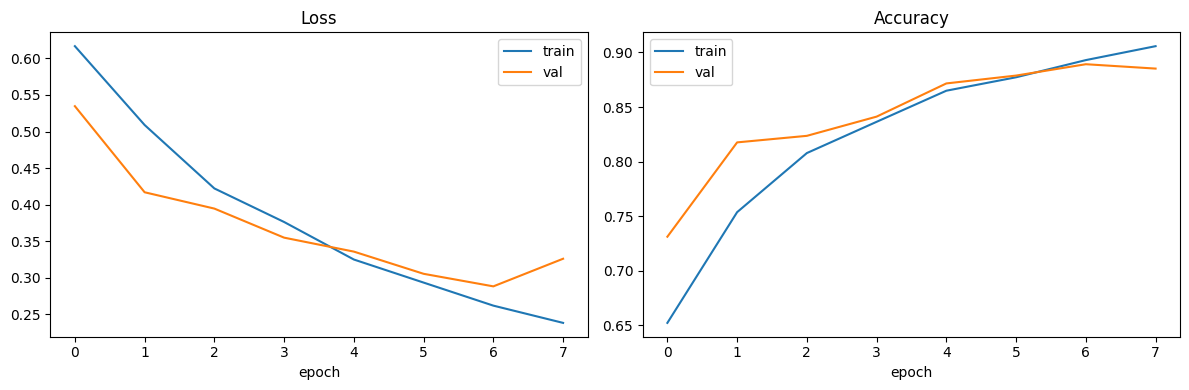

In [5]:
def run_epoch(loader, train=True):
    model.train(train)
    total_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for x, lengths, y in loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            logits = model(x, lengths)            # lengths stay on CPU for packing
            loss = criterion(logits, y)
            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)  # avoid exploding grads
                optimizer.step()
            total_loss += loss.item() * y.size(0)
            correct += ((logits > 0).float() == y).sum().item()
            n += y.size(0)
    return total_loss / n, correct / n

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_loss, bad_epochs = float("inf"), 0

for epoch in range(1, EPOCHS + 1):
    start = time.time()
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    va_loss, va_acc = run_epoch(val_loader, train=False)
    scheduler.step(va_loss)

    for k, v in zip(history, [tr_loss, va_loss, tr_acc, va_acc]):
        history[k].append(v)
    print(f"Epoch {epoch:02d}/{EPOCHS} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
          f"val loss {va_loss:.4f} acc {va_acc:.4f} | {time.time() - start:.0f}s")

    if va_loss < best_val_loss:
        best_val_loss, bad_epochs = va_loss, 0
        torch.save(model.state_dict(), MODEL_PATH)
        print("  -> best model saved")
    else:
        bad_epochs += 1
        if bad_epochs >= PATIENCE:
            print("Early stopping.")
            break

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="train"); axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].set_xlabel("epoch"); axes[0].legend()
axes[1].plot(history["train_acc"], label="train"); axes[1].plot(history["val_acc"], label="val")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("epoch"); axes[1].legend()
plt.tight_layout(); plt.show()

## 6. Test evaluation: confusion matrix and classification report
Loads the best model and reports accuracy, precision, recall, and F1-score on the test set.

Test accuracy: 0.8834

Classification report:
              precision    recall  f1-score   support

    Negative     0.8802    0.8875    0.8838     12500
    Positive     0.8866    0.8792    0.8829     12500

    accuracy                         0.8834     25000
   macro avg     0.8834    0.8834    0.8834     25000
weighted avg     0.8834    0.8834    0.8834     25000

Confusion matrix:
 [[11094  1406]
 [ 1510 10990]]


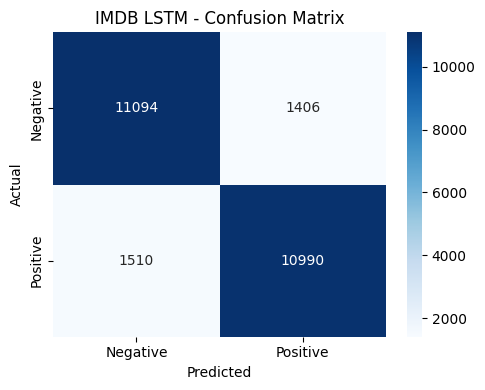

In [6]:
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))

@torch.no_grad()
def get_probs(loader):
    model.eval()
    probs, labels = [], []
    for x, lengths, y in loader:
        probs.append(torch.sigmoid(model(x.to(device), lengths)).cpu())
        labels.append(y)
    return torch.cat(probs).numpy(), torch.cat(labels).numpy().astype(int)

test_probs, test_true = get_probs(test_loader)
test_pred = (test_probs >= 0.5).astype(int)

class_names = ["Negative", "Positive"]
print(f"Test accuracy: {accuracy_score(test_true, test_pred):.4f}\n")
print("Classification report:")
print(classification_report(test_true, test_pred, target_names=class_names, digits=4))

cm = confusion_matrix(test_true, test_pred)
print("Confusion matrix:\n", cm)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("IMDB LSTM - Confusion Matrix")
plt.tight_layout(); plt.show()

## 7. Precision-recall tradeoff
Plots the precision-recall curve and shows how precision, recall, and F1 change as the decision threshold moves.

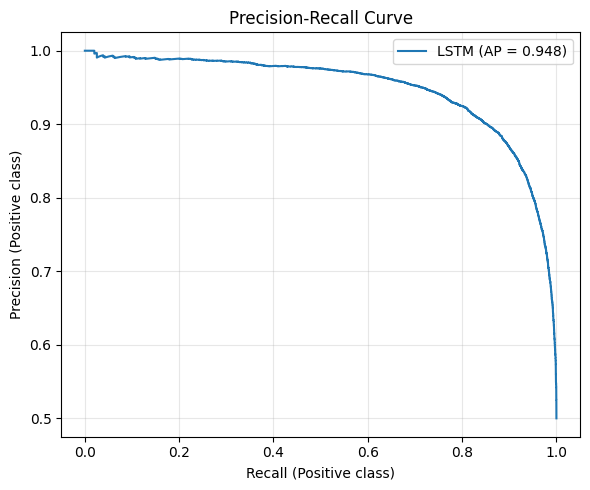

Effect of the decision threshold on the Positive class:
threshold | precision |  recall |     f1
      0.2 |    0.8157 |  0.9430 | 0.8747
      0.3 |    0.8449 |  0.9221 | 0.8818
      0.4 |    0.8670 |  0.9015 | 0.8839
      0.5 |    0.8866 |  0.8792 | 0.8829
      0.6 |    0.9004 |  0.8517 | 0.8754
      0.7 |    0.9166 |  0.8173 | 0.8641
      0.8 |    0.9331 |  0.7718 | 0.8448


In [7]:
precision, recall, thresholds = precision_recall_curve(test_true, test_probs)
ap = average_precision_score(test_true, test_probs)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"LSTM (AP = {ap:.3f})")
plt.xlabel("Recall (Positive class)"); plt.ylabel("Precision (Positive class)")
plt.title("Precision-Recall Curve"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("Effect of the decision threshold on the Positive class:")
print(f"{'threshold':>9} | {'precision':>9} | {'recall':>7} | {'f1':>6}")
for t in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    p = (test_probs >= t).astype(int)
    print(f"{t:>9.1f} | {precision_score(test_true, p, zero_division=0):>9.4f} | "
          f"{recall_score(test_true, p):>7.4f} | {f1_score(test_true, p):>6.4f}")

## 8. Try the model on my own reviews 

### Decided to write 3 sample reviews and test them

In [8]:
@torch.no_grad()
def predict_sentiment(text, threshold=0.5):
    model.eval()
    x, lengths = encode_and_pad([tokenize(text)])
    prob = torch.sigmoid(model(x.to(device), lengths)).item()
    label = "Positive" if prob >= threshold else "Negative"
    return label, prob

for review in ["This movie was absolutely wonderful, the acting was superb and I loved every minute.",
               "What a waste of time. The plot was boring and the characters were terrible.",
               "It was okay, not great but not the worst film I have seen this year."]:
    label, prob = predict_sentiment(review)
    print(f"{label:8s} (p_pos={prob:.3f}) | {review}")

Positive (p_pos=0.993) | This movie was absolutely wonderful, the acting was superb and I loved every minute.
Negative (p_pos=0.001) | What a waste of time. The plot was boring and the characters were terrible.
Negative (p_pos=0.002) | It was okay, not great but not the worst film I have seen this year.


## 9. Interpretation: why the precision-recall tradeoff matters in sentiment classification

The model outputs a probability, and a threshold (0.5) turns it into a label. Moving the threshold trades one kind of mistake for the other:

- **Raising the threshold** increases precision. When the model says "positive," it is more often right. But recall drops, because more truly positive reviews get missed.
- **Lowering the threshold** does the opposite: recall goes up, and more false positives get through.

Which one to favor depends on what the predictions are used for:

- **Monitoring customer complaints:** missing an angry customer usually costs more than reviewing a few extra messages, so high recall on the negative class matters most.
- **Displaying reviews as "recommended" or quoting them in ads:** a negative review wrongly labeled positive is embarrassing, so precision on the positive class matters more.

Sentiment is also naturally ambiguous. Sarcasm ("great, another two hours I'll never get back"), mixed reviews, and negations put many reviews near the decision boundary. Accuracy alone hides which kind of mistake the model is making. The confusion matrix, per-class precision and recall, and F1 (which balances the two) show that. The threshold table in step 7 shows how the model can be tuned to the cost of each error instead of accepting 0.5 as the default.